In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# convert labels from 2D shape to 1D shape
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [4]:
# Normalize pixel values from 0–255 to 0–1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0


In [5]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# 2 Data Augmentation
# This randomly modifies images during training
# Helps prevent overfitting and improves generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # randomly flips image left-right during training

    layers.RandomRotation(0.1),      # randomly rotates image up to 10%

    layers.RandomZoom(0.1),       # randomly zooms image up to 10%
])


In [6]:
model = models.Sequential([

    data_augmentation,     # apply augmentation only during training


    # Conv2D → convolution layer
    # 32 → number of filters (feature detectors)
    # (3,3) → kernel size
    # padding='same' → output size same as input
    # input_shape=(32,32,3) → image size (height, width, RGB channels)

    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),   # reduce image size by taking maximum value in 2x2 region

    layers.Conv2D(64, (3,3), padding='same'), # second convolution layer with 64 filters
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

   # Dense - Every neuron connects to all neurons from previous layer.
   # Dense - (Fully Connected Layer)It takes all extracted features and answers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),   # randomly turn off 50% neurons during training (prevents overfitting)


    layers.Dense(10, activation='softmax')    # softmax → converts output into probabilities
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

#  Compile Model


optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # loss function used for integer labels
    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,    # wait 5 epochs before stopping
    restore_best_weights=True    # restore weights from best epoch
)

history = model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=64,     # number of images processed at once
    validation_data=(test_images, test_labels),
    callbacks=[early_stop]   # only early stopping
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 187s 234ms/step - accuracy: 0.2772 - loss: 1.9855 - val_accuracy: 0.4173 - val_loss: 1.6117
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 190s 243ms/step - accuracy: 0.4102 - loss: 1.6128 - val_accuracy: 0.5647 - val_loss: 1.2366
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 232ms/step - accuracy: 0.4501 - loss: 1.5039 - val_accuracy: 0.4734 - val_loss: 1.5762
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step - accuracy: 0.4744 - loss: 1.4326 - val_accuracy: 0.5567 - val_loss: 1.1988
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 184s 235ms/step - accuracy: 0.4897 - loss: 1.3960 - val_accuracy: 0.5349 - val_loss: 1.3147
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step - accuracy: 0.5069 - loss: 1.3515 - val_accuracy: 0.5359 - val_loss: 1.3355
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 206s 237ms/step - accuracy: 0.5207 - loss: 1.3273 - val_accuracy: 0.5584 - val_loss: 1.3004
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 182s 233ms/step - accuracy: 0.5355 -

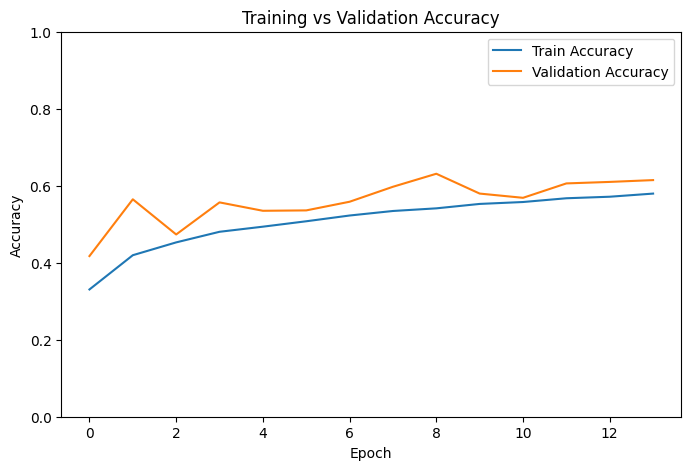

In [8]:
# Plot Accuracy
# =========================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.ylim(0,1)
plt.show()



In [9]:
 #8️⃣ Evaluate Model
# =========================

test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6322 - loss: 1.0637
Final Test Accuracy: 0.6310999989509583


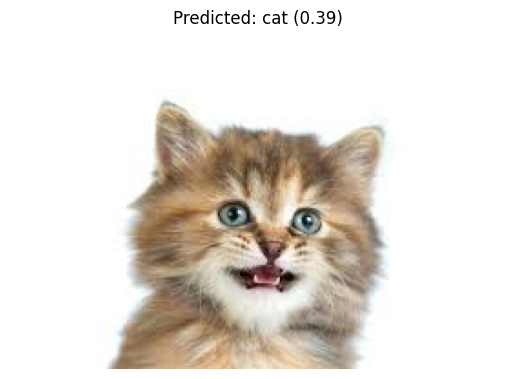

Predicted Class: cat
Confidence: 0.38969600200653076


In [23]:
# 9️⃣ External Image Prediction
# =========================

def predict_external_image(image_path):

    # Load ORIGINAL image (no resize)
    original_img = tf.keras.preprocessing.image.load_img(image_path)

    # Create resized copy ONLY for model
    resized_img = original_img.resize((32, 32))

    img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class_index = np.argmax(prediction)
    predicted_class = class_names[predicted_class_index]
    confidence = float(np.max(prediction))

    # Show ORIGINAL image
    plt.imshow(original_img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence)

predict_external_image("/content/images (1).jpg")

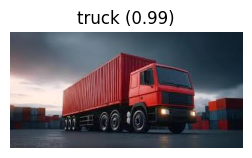

Image: truck_cnn.jpg
Predicted: truck
Confidence: 0.9896345734596252
----------------------------------------


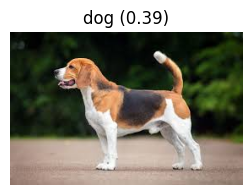

Image: cnn_input3.jpg
Predicted: dog
Confidence: 0.3903506100177765
----------------------------------------


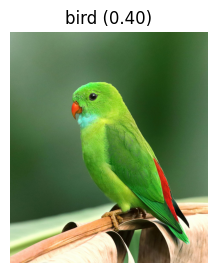

Image: bird_cnn_input.jpg
Predicted: bird
Confidence: 0.3971143662929535
----------------------------------------


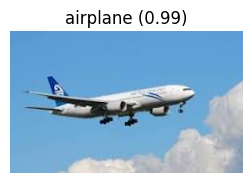

Image: airplane_cnn.jpg
Predicted: airplane
Confidence: 0.9881513118743896
----------------------------------------


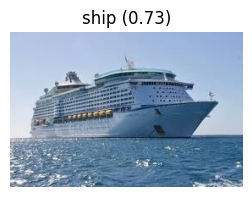

Image: ship_cnn.jpg
Predicted: ship
Confidence: 0.7295747399330139
----------------------------------------


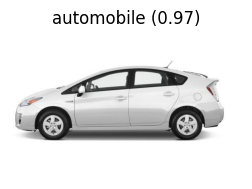

Image: cnn_input2.jpg
Predicted: automobile
Confidence: 0.9686435461044312
----------------------------------------


In [43]:
import os

def predict_folder(folder_path):

    for file_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file_name)

        original_img = tf.keras.preprocessing.image.load_img(image_path)
        resized_img = original_img.resize((32, 32))

        img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
        img_array = img_array.astype("float32") / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)

        predicted_class_index = np.argmax(prediction)
        predicted_class = class_names[predicted_class_index]
        confidence = float(np.max(prediction))

        plt.figure(figsize=(3,3))
        plt.imshow(original_img)
        plt.title(f"{predicted_class} ({confidence:.2f})")
        plt.axis("off")
        plt.show()

        print("Image:", file_name)
        print("Predicted:", predicted_class)
        print("Confidence:", confidence)
        print("-" * 40)

predict_folder("/content/testImages")

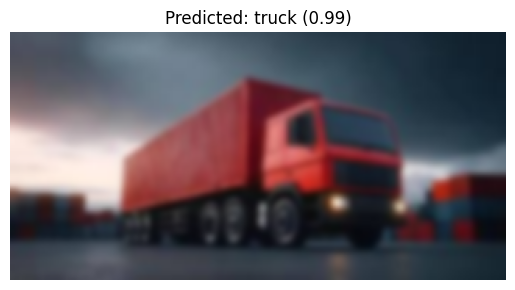

Predicted Class: truck
Confidence: 0.986393392086029


In [42]:
# The below for blur images

from PIL import ImageFilter
def predict_external_image(image_path, blur_radius=0):

    # Load ORIGINAL image
    original_img = tf.keras.preprocessing.image.load_img(image_path)

    # 🔹 Apply blur if radius > 0
    if blur_radius > 0:
        original_img = original_img.filter(
            ImageFilter.GaussianBlur(radius=blur_radius)
        )

    # Resize for model
    resized_img = original_img.resize((32, 32))

    img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class_index = np.argmax(prediction)
    predicted_class = class_names[predicted_class_index]
    confidence = float(np.max(prediction))

    # Show image
    plt.imshow(original_img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence)


# Light blur
predict_external_image("/content/truck_cnn.jpg", blur_radius=2)



In [ ]:
# The below is for folder


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import ImageFilter

def predict_external_folder(folder_path, blur_radius=0):

    # Loop through all files in folder
    for filename in os.listdir(folder_path):

        # Process only image files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):

            image_path = os.path.join(folder_path, filename)

            # Load ORIGINAL image
            original_img = tf.keras.preprocessing.image.load_img(image_path)

            # 🔹 Apply blur if radius > 0
            if blur_radius > 0:
                original_img = original_img.filter(
                    ImageFilter.GaussianBlur(radius=blur_radius)
                )

            # Resize for model
            resized_img = original_img.resize((32, 32))

            img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
            img_array = img_array.astype("float32") / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_array, verbose=0)

            predicted_class_index = np.argmax(prediction)
            predicted_class = class_names[predicted_class_index]
            confidence = float(np.max(prediction))

            # Show image
            plt.imshow(original_img)
            plt.title(f"{filename}\nPredicted: {predicted_class} ({confidence:.2f})")
            plt.axis("off")
            plt.show()

            print("Image:", filename)
            print("Predicted Class:", predicted_class)
            print("Confidence:", confidence)
            print("-" * 40)


# 🔹 Example Usage
print(os.listdir("/content/testImages"))
predict_external_folder("/content/testImages", blur_radius=2)
